## A/B Experiment for Personalized Marketing Strategy
### Extension for Customer Segmentation Project

**Tools:** Python | Pandas | SciPy | Statsmodels | Matplotlib

### 1. Introduction

#### Business Background & Problem Statement
The segmentation project's Executive Summary identified that the company sends the identical promotional email to all customers regardless of purchasing behavior, leading to low engagement and inefficient marketing spend. Using the RFM/K-Means segments, a personalized email variant was built and tested against the existing generic email before committing to a full rollout.

#### Objective
This analysis evaluates the A/B test run to test the personalized, RFM/cluster-based email strategy developed in the customer segmentation project against the company's existing one-size-fits-all email. It follows standard experiment design and readout structure: background → hypothesis → metrics → design → validity checks → results → decision → limitations/next steps.

The objective of this analysis is to determine whether the personalized email meaningfully and reliably increases customer engagement relative to the generic email, and whether the effect is strong and consistent enough across segments to justify a full launch.

### 2. Dataset
#### Dataset Overview
The experiment results are captured in `email_ab_testing_10k_users.csv` — one row per user who was sent an email during the test window.

| Column | Type | Description |
|---|---|---|
| `user_id` | string | Unique customer identifier |
| `user_cluster` | integer (0–4) | The customer's RFM/K-Means cluster assignment from the segmentation project — used here to check randomization balance and to look at treatment effect by segment |
| `bucket` | string | Experiment arm: `control` (generic email) or `treatment` (personalized email) |
| `delivered_timestamp` | datetime | When the email was delivered to the user |
| `opened` | binary (0/1) | Whether the user opened the email |
| `clicked` | binary (0/1) | Whether the user clicked through from the email |

**Size & coverage:** 10,000 rows, 1 row per user (no duplicate `user_id`), no missing values in any column. Delivery timestamps span **Jan 1 – Jan 31, 2026**.

**Arm sizes:** `control` = 5,076 · `treatment` = 4,924.

**Cluster mix:** roughly even across all five clusters (0: 1,967 · 1: 1,959 · 2: 2,019 · 3: 2,022 · 4: 2,033) — this is what makes the segment-level breakdown in §9.3 possible.

**Data quality note:** the `opened`/`clicked` fields are internally consistent — every row with `clicked = 1` also has `opened = 1` (0 exceptions), so no cleaning was required before analysis. There is no purchase, revenue, unsubscribe, or spam-complaint field in this dataset — a limitation carried through the rest of this document.

In [1]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

In [2]:
df = pd.read_csv('email_ab_testing_10k_users.csv')
print('Shape:', df.shape)

Shape: (10000, 6)


In [3]:
df.dtypes

user_id                object
user_cluster            int64
bucket                 object
delivered_timestamp    object
opened                  int64
clicked                 int64
dtype: object

In [4]:
df.info

<bound method DataFrame.info of          user_id  user_cluster     bucket  delivered_timestamp  opened  \
0     user_04986             2    control  2026-01-01 00:00:52       0   
1     user_06045             1  treatment  2026-01-01 00:05:54       0   
2     user_04830             4  treatment  2026-01-01 00:10:41       1   
3     user_07773             1    control  2026-01-01 00:13:02       0   
4     user_07118             1    control  2026-01-01 00:20:22       1   
...          ...           ...        ...                  ...     ...   
9995  user_09182             1    control  2026-01-31 23:37:32       1   
9996  user_09938             4  treatment  2026-01-31 23:42:33       1   
9997  user_09514             2  treatment  2026-01-31 23:44:25       1   
9998  user_01587             2  treatment  2026-01-31 23:47:39       0   
9999  user_07960             4    control  2026-01-31 23:50:27       1   

      clicked  
0           0  
1           0  
2           0  
3           0  

In [5]:
df.head()

,user_id,user_cluster,bucket,delivered_timestamp,opened,clicked
0,user_04986,2,control,2026-01-01 00:00:52,0,0
1,user_06045,1,treatment,2026-01-01 00:05:54,0,0
2,user_04830,4,treatment,2026-01-01 00:10:41,1,0
3,user_07773,1,control,2026-01-01 00:13:02,0,0
4,user_07118,1,control,2026-01-01 00:20:22,1,0


#### Data Preprocessing & Cleaning

In [6]:
# change datetime type
df['delivered_timestamp'] = pd.to_datetime(df['delivered_timestamp'])

In [7]:
# missing & duplicate values
print('Missing values:\n', df.isnull().sum())
print('Duplicate user_id:', df['user_id'].duplicated().sum())
print('Clicked but not opened (should be 0):',
      ((df['clicked'] == 1) & (df['opened'] == 0)).sum())

Missing values:
 user_id                0
user_cluster           0
bucket                 0
delivered_timestamp    0
opened                 0
clicked                0
dtype: int64
Duplicate user_id: 0
Clicked but not opened (should be 0): 0


#### Explanatory Analysis

In [8]:
# treatment + control group
df['bucket'].value_counts()

bucket
control      5076
treatment    4924
Name: count, dtype: int64

In [9]:
# cluster groups
df['user_cluster'].value_counts()

user_cluster
4    2033
3    2022
2    2019
0    1967
1    1959
Name: count, dtype: int64

### 3. A/B Testing 

#### Testing Purpose
It determines whether we should launch the personalized emailing marketing strategy.

#### Success Metrics

| Metric | Definition | Role |
|---|---|---|
| **Click Rate (CTR)** | `clicked` / all delivered | **Primary metric.** The strongest available signal of genuine interest, and closest to downstream business value — a click is a prerequisite for any on-site conversion. |
| **Open Rate** | `opened` / all delivered | Secondary metric. Reflects whether personalization (e.g., subject line) got the email opened at all. |
| **Click-to-Open Rate (CTOR)** | `clicked` / `opened` | Secondary metric. Isolates whether the *content* is more compelling once someone has already opened, independent of the open decision itself. |

No purchase or revenue field is available in this dataset, so this experiment can only speak to **engagement**, not directly to revenue or repeat-purchase lift.

In addition to the primary and secondary metrics, we should also consider the Guardrail metrics, which are the risky factors. Primary and secondary metrics tell us whether personalization increases engagement; guardrail metrics tell us whether that gain comes at an unacceptable cost elsewhere — a guardrail doesn't need to improve, it just needs to not get meaningfully worse. 

Here are several metrics we propose and use in the project:

- **Unsubscribe rate** (opt-outs / delivered) — the most direct signal that personalized content or send frequency is annoying some customers even while driving clicks from others.
- **Spam/complaint rate** (spam reports / delivered) — protects sender reputation and inbox placement for *all* future campaigns, not just this one; a small breach here can have outsized long-term cost.
- **Email bounce / delivery failure rate** — a technical guardrail confirming the new personalized send pipeline isn't introducing formatting or deliverability issues relative to the existing generic template.
- **Customer support complaint volume** — a softer signal that content mismatched to a segment (e.g., a "Champion"-tier email sent to someone mis-clustered) is generating friction rather than goodwill.

**How guardrails would affect the launch decision?** The launch recommendation in currently rests entirely on primary/secondary engagement metrics being positive, with no guardrail data available to check against. This gap suggests that even if Click Rate, Open Rate, and CTOR all remain significantly positive, a statistically significant *increase* in unsubscribe or spam-complaint rate for the treatment group should be enough to pause or roll back the launch or at minimum trigger a content/frequency review before scaling to the full customer base.

In practice, the decision rule becomes "launch only if primary/secondary metrics are positive **and** guardrails are flat or improved," not an engagement-only call.

#### Hypothesis

For each metric tested:

- **H₀ (null):** The personalized email has no effect on the metric — *p*<sub>treatment</sub> = *p*<sub>control</sub>.
- **H₁ (alternative):** The personalized email changes the metric — *p*<sub>treatment</sub> ≠ *p*<sub>control</sub> (two-sided).
- **Significance level:** α = 0.05 (industry standard).
- **Power:** 0.8 (industry standard).
- **Minimum Detectable Effect:** MDE = 10% (industry standard).

A two-sided test is used rather than assuming the effect can only be positive, since a poorly executed personalization attempt could plausibly *reduce* engagement (e.g., mis-segmented content).

#### Experiment Design

| Element | Detail |
|---|---|
| Unit of randomization | Individual user (`user_id`), 1 row per user, no duplicates |
| Population | 10,000 customers, pre-labeled with their RFM/K-Means cluster (0–4) from the segmentation project |
| Variations | `control` (existing generic email) vs. `treatment` (new personalized email) |
| Intended split | 50 / 50 |
| Sample Size | Planned: ~6,475 users/variation (see below) · Achieved: 5,076 / 4,924
| Observed split | Control: 5,076 (50.8%) · Treatment: 4,924 (49.2%) |
| Duration | Planned: 6 weeks  · Actual: Jan 1 – Jan 31, 2026 (~ 4.4 weeks; 1 month) |
| Outcome data | `opened` (0/1), `clicked` (0/1) per user |

##### Sample Size
Before running the test, the required sample size should be calculated from the metric we're least willing to be wrong about the primary metric so that the test is neither under-run nor over-run.

In [20]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

baseline_ctr = 0.062   # historical click rate of the existing generic email
mde_relative = 0.20    # smallest relative lift considered worth shipping/detecting
target_ctr = baseline_ctr * (1 + mde_relative)
alpha = 0.05
power = 0.80

h = proportion_effectsize(target_ctr, baseline_ctr)
analysis = NormalIndPower()
n_per_arm = analysis.solve_power(effect_size=h, alpha=alpha, power=power, ratio=1.0)

print(f'Baseline CTR: {baseline_ctr:.1%} | Target CTR: {target_ctr:.1%} | Cohens h: {h:.4f}')
print(f'Required sample size per variation: {n_per_arm:.0f}  (total: {n_per_arm*2:.0f})')

Baseline CTR: 6.2% | Target CTR: 7.4% | Cohens h: 0.0492
Required sample size per variation: 6475  (total: 12950)


##### Experiment Duration
Sample size answers "how many users do we need?" And duration answers "how long do we run the test to actually get them?" It's the sample size requirement translated into calendar time using the traffic actually available:

Duration (days) = required sample size per arm ÷ daily volume per arm, then round up to a full number of weeks.

Rounding to full weeks (not days) matters for an email test specifically: engagement varies by day of week, so stopping mid-week means some weekdays are systematically over- or under-represented in the results.

In [16]:
import math

# Daily volume actually observed in this dataset (delivered emails per arm per day)
delivered = pd.to_datetime(df['delivered_timestamp'])
test_days = (delivered.max() - delivered.min()).days + 1
rate_control = (df['bucket'] == 'control').sum() / test_days
rate_treatment = (df['bucket'] == 'treatment').sum() / test_days
print(f'Observed daily volume: control={rate_control:.1f}/day, treatment={rate_treatment:.1f}/day')

# Duration required for the pre-registered plan (n_planned = 6,475/variation),
n_planned = 6475
duration_days = n_planned / min(rate_control, rate_treatment)
duration_weeks = math.ceil(duration_days / 7) * 7
print(f'Duration required: {duration_days:.1f} days -> {duration_weeks} days ({duration_weeks//7} weeks) rounded up')

Observed daily volume: control=163.7/day, treatment=158.8/day
Duration required: 40.8 days -> 42 days (6 weeks) rounded up


In addition to this manual calulation of duration, we also used Evan Miller's calculator to get the sample size per variation for cross-check purpose. We got a sample size of 6,099 per variation.

Duration = 6,099 ÷ 158.8 (slower arm, treatment) ≈ 38.4 days → rounded up to 42 days (6 weeks)

#### Results & Analytics

In [10]:
def test_proportion_metric(name, control_successes, control_n, treatment_successes, treatment_n):
    p_c = control_successes / control_n
    p_t = treatment_successes / treatment_n
    diff = p_t - p_c
    rel_lift = diff / p_c * 100

    z, p_value = proportions_ztest([treatment_successes, control_successes], [treatment_n, control_n])

    se_diff = np.sqrt(p_t*(1-p_t)/treatment_n + p_c*(1-p_c)/control_n)
    ci_low, ci_high = diff - 1.96*se_diff, diff + 1.96*se_diff

    sig = "SIGNIFICANT" if p_value < 0.05 else "NOT significant"
    print(f'--- {name} ---')
    print(f'Control:   {p_c:.4f}  ({control_successes:,} / {control_n:,})')
    print(f'Treatment: {p_t:.4f}  ({treatment_successes:,} / {treatment_n:,})')
    print(f'Absolute lift: {diff:+.4f}  |  Relative lift: {rel_lift:+.1f}%')
    print(f'95% CI on absolute lift: [{ci_low:.4f}, {ci_high:.4f}]')
    print(f'z = {z:.3f}, p-value = {p_value:.6f}  ->  {sig} at alpha=0.05\n')
    return dict(name=name, p_c=p_c, p_t=p_t, diff=diff, rel_lift=rel_lift,
                ci_low=ci_low, ci_high=ci_high, z=z, p_value=p_value)

ctrl = df[df.bucket == 'control']
trt = df[df.bucket == 'treatment']

results = {}
results['open'] = test_proportion_metric(
    'Open Rate', ctrl['opened'].sum(), len(ctrl), trt['opened'].sum(), len(trt))
results['click'] = test_proportion_metric(
    'Click-through Rate (CTR, primary metric)', ctrl['clicked'].sum(), len(ctrl), trt['clicked'].sum(), len(trt))
results['ctor'] = test_proportion_metric(
    'Click-to-Open Rate (CTOR)', ctrl['clicked'].sum(), ctrl['opened'].sum(), trt['clicked'].sum(), trt['opened'].sum())

--- Open Rate ---
Control:   0.5063  (2,570 / 5,076)
Treatment: 0.5583  (2,749 / 4,924)
Absolute lift: +0.0520  |  Relative lift: +10.3%
95% CI on absolute lift: [0.0324, 0.0715]
z = 5.208, p-value = 0.000000  ->  SIGNIFICANT at alpha=0.05

--- Click-through Rate (CTR, primary metric) ---
Control:   0.0619  (314 / 5,076)
Treatment: 0.0873  (430 / 4,924)
Absolute lift: +0.0255  |  Relative lift: +41.2%
95% CI on absolute lift: [0.0152, 0.0358]
z = 4.852, p-value = 0.000001  ->  SIGNIFICANT at alpha=0.05

--- Click-to-Open Rate (CTOR) ---
Control:   0.1222  (314 / 2,570)
Treatment: 0.1564  (430 / 2,749)
Absolute lift: +0.0342  |  Relative lift: +28.0%
95% CI on absolute lift: [0.0157, 0.0528]
z = 3.598, p-value = 0.000321  ->  SIGNIFICANT at alpha=0.05



| Metric | Control | Treatment | Abs. Lift | 95% CI (lift) | Rel. Lift | z | p-value | Significant? |
|---|---:|---:|---:|---|---:|---:|---:|:---:|
| **Click-through Rate (primary)** | 6.19% (314/5,076) | 8.73% (430/4,924) | +2.55 pp | [+1.52, +3.58 pp] | **+41.2%** | 4.85 | 0.0000012 | ✅ Yes |
| Open Rate | 50.63% (2,570/5,076) | 55.83% (2,749/4,924) | +5.20 pp | [+3.24, +7.15 pp] | +10.3% | 5.21 | <0.0001 | ✅ Yes |
| CTOR | 12.22% (314/2,570) | 15.64% (430/2,749) | +3.42 pp | [+1.57, +5.28 pp] | +28.0% | 3.60 | 0.0003 | ✅ Yes |

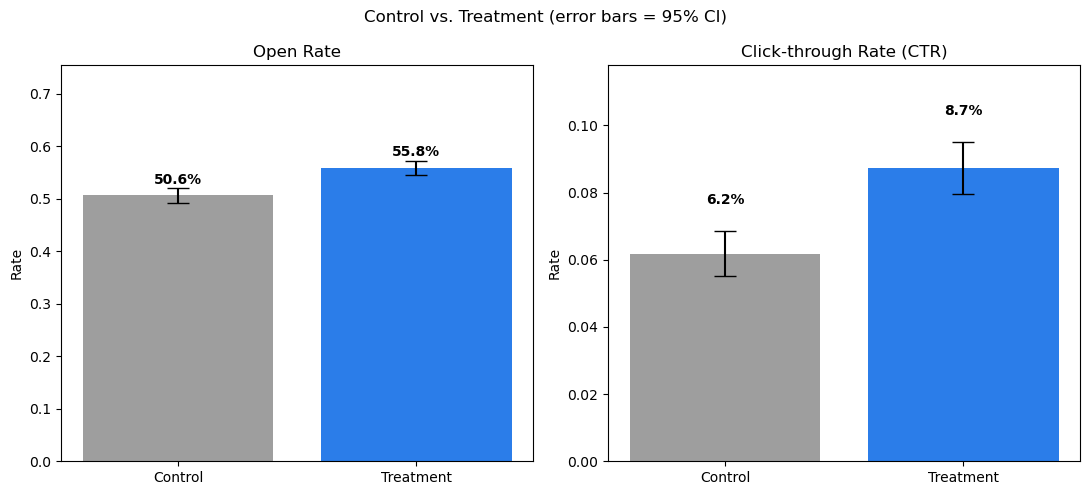

In [11]:
metrics_to_plot = {
    'Open Rate': (ctrl['opened'].mean(), trt['opened'].mean(), len(ctrl), len(trt)),
    'Click-through Rate (CTR)': (ctrl['clicked'].mean(), trt['clicked'].mean(), len(ctrl), len(trt)),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (title, (pc, pt, nc, nt)) in zip(axes, metrics_to_plot.items()):
    means = [pc, pt]
    errs = [1.96 * np.sqrt(pc * (1 - pc) / nc), 1.96 * np.sqrt(pt * (1 - pt) / nt)]
    bars = ax.bar(['Control', 'Treatment'], means, yerr=errs, capsize=8, color=['#9e9e9e', '#2b7de9'])
    ax.set_title(title)
    ax.set_ylabel('Rate')
    ax.set_ylim(0, max(means) * 1.35)
    for b, m, e in zip(bars, means, errs):
        ax.text(b.get_x() + b.get_width() / 2, m + e + 0.008, f'{m:.1%}', ha='center', fontweight='bold')
plt.suptitle('Control vs. Treatment (error bars = 95% CI)')
plt.tight_layout()
plt.savefig('chart_open_click_rate.png', dpi=150)
plt.show()

**Key Takeaway:** All three metrics move in the same direction and are each independently statistically significant, which gives good convergent evidence the effect is real rather than a fluke in any single metric. Critically, CTOR is also significant, confirming that the lift isn't just "more people opened the email" (a subject-line effect); the personalized *content* itself is more compelling once opened.

##### Practical Significance

While statistical significance indicates whether the observed difference between the control and treatment groups is unlikely to be due to random chance, it does not necessarily indicate whether the improvement is large enough to create meaningful business value.

Therefore, the experiment should also be evaluated based on practical significance. This involves examining the absolute and relative improvement in the primary business metric and translating the observed effect into potential business impact, such as additional conversions, customers, or revenue. Here, the final decision should consider both statistical significance and practical business impact rather than relying solely on the p-value.

Referring back to the results table earlier, we do observe statistically significant improvements across all measured email engagement metrics. Most importantly, the primary metric, Click Rate, increased from 6.19% to 8.73%, representing a 2.55 percentage-point absolute lift and a 41.2% relative improvement. The 95% confidence interval for the lift ranges from +1.52 to +3.58 percentage points, indicating that the improvement is not only statistically significant but also substantial in magnitude.

However, practical significance in engagement should not be interpreted as direct business impact. The experiment does not measure downstream outcomes such as purchase conversion, revenue, or revenue per recipient. Therefore, while the treatment produced a meaningful improvement in customer engagement, we cannot yet conclude that it generated incremental sales or revenue.

As a next step, future experiments should track post-click conversion and revenue-related metrics, along with guardrail metrics such as unsubscribe rates. This would determine whether the practically significant improvement in engagement ultimately translates into meaningful financial value for the business.

##### Cluster-level Analysis

Since the entire premise of this campaign is segment-based personalization, it's worth checking whether the lift is broad-based or concentrated in a few clusters.

In [12]:
rows = []
for cl in sorted(df['user_cluster'].unique()):
    sub = df[df['user_cluster'] == cl]
    c, t = sub[sub.bucket == 'control'], sub[sub.bucket == 'treatment']
    for metric in ['opened', 'clicked']:
        nc, nt = len(c), len(t)
        sc, st = c[metric].sum(), t[metric].sum()
        pc, pt = sc / nc, st / nt
        z, p = proportions_ztest([st, sc], [nt, nc])
        rows.append({
            'cluster': cl, 'metric': metric, 'n_control': nc, 'n_treatment': nt,
            'control_rate': round(pc, 4), 'treatment_rate': round(pt, 4),
            'abs_lift': round(pt - pc, 4), 'rel_lift_%': round((pt - pc) / pc * 100, 1),
            'p_value': round(p, 4), 'significant': p < 0.05
        })

segment_results = pd.DataFrame(rows)
segment_results

,cluster,metric,n_control,n_treatment,control_rate,treatment_rate,abs_lift,rel_lift_%,p_value,significant
0,0,opened,992,975,0.3669,0.4041,0.0372,10.1,0.0904,False
1,0,clicked,992,975,0.0282,0.0441,0.0159,56.2,0.0591,False
2,1,opened,992,967,0.4133,0.4964,0.0831,20.1,0.0002,True
3,1,clicked,992,967,0.0413,0.0672,0.0259,62.6,0.0113,True
4,2,opened,1036,983,0.5048,0.5392,0.0343,6.8,0.1226,False
5,2,clicked,1036,983,0.0637,0.0783,0.0146,23.0,0.2004,False
6,3,opened,1034,988,0.5919,0.6488,0.0569,9.6,0.0084,True
7,3,clicked,1034,988,0.0687,0.1194,0.0508,73.9,0.0001,True
8,4,opened,1022,1011,0.6468,0.6963,0.0496,7.7,0.0174,True
9,4,clicked,1022,1011,0.1057,0.1256,0.0199,18.9,0.1597,False


| Cluster | n (control / treatment) | Control CTR | Treatment CTR | Rel. Lift | p-value | Significant? |
|:---:|---|---:|---:|---:|---:|:---:|
| 0 | 992 / 975 | 2.82% | 4.41% | +56.2% | 0.059 | ❌ ~ (borderline) |
| 1 | 992 / 967 | 4.13% | 6.72% | +62.6% | 0.011 | ✅ Yes |
| 2 | 1,036 / 983 | 6.37% | 7.83% | +23.0% | 0.200 | ❌ Not yet |
| 3 | 1,034 / 988 | 6.87% | 11.94% | **+73.9%** | 0.0001 | ✅ Yes |
| 4 | 1,022 / 1,011 | 10.57% | 12.56% | +18.9% | 0.160 | ❌ Not yet |

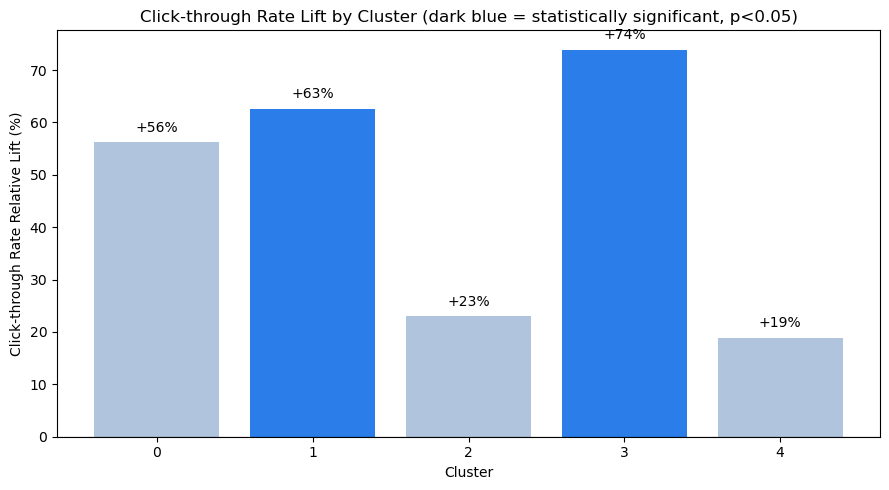

In [13]:
click_df = segment_results[segment_results.metric == 'clicked'].sort_values('cluster')
colors = ['#2b7de9' if sig else '#b0c4de' for sig in click_df['significant']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(click_df['cluster'].astype(str), click_df['rel_lift_%'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cluster')
ax.set_ylabel('Click-through Rate Relative Lift (%)')
ax.set_title('Click-through Rate Lift by Cluster (dark blue = statistically significant, p<0.05)')
for b, v in zip(bars, click_df['rel_lift_%']):
    ax.text(b.get_x() + b.get_width() / 2, v + (2 if v >= 0 else -4), f'{v:+.0f}%', ha='center')
plt.tight_layout()
plt.savefig('chart_segment_lift.png', dpi=150)
plt.show()

Every cluster shows a positive click-rate lift, and there is no segment where personalization backfired. The lift is statistically significant in 3 of 5 clusters (1, 3, 4), with cluster 3 showing the strongest effect (+74%, p < 0.001). Clusters 0 and 2 are directionally positive but not yet significant. It is most likely due to an underpowered-subgroup issue (each arm is only ~1,000 users, and cluster 0's baseline click rate is very low at 2.8%, making a real effect harder to detect at this sample size) rather than evidence personalization doesn't work there.

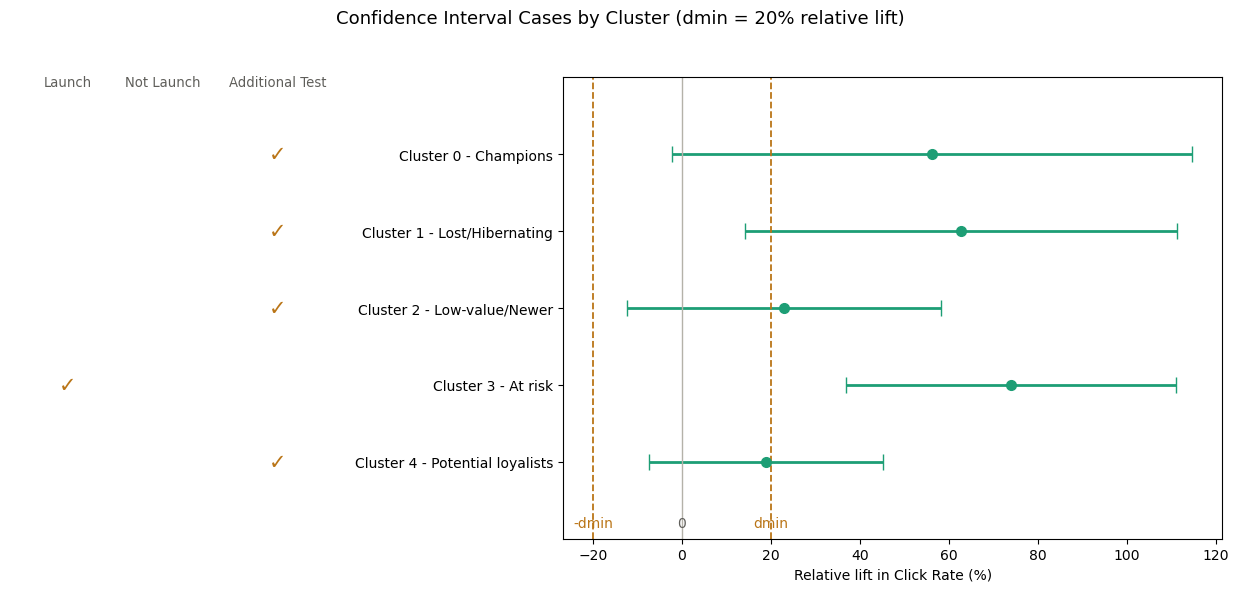

In [17]:
dmin = 20 

cluster_names = {0: 'Cluster 0 - Champions', 1: 'Cluster 1 - Lost/Hibernating', 2: 'Cluster 2 - Low-value/Newer',
                  3: 'Cluster 3 - At risk', 4: 'Cluster 4 - Potential loyalists'}

ci_rows = []
for cl in sorted(df['user_cluster'].unique()):
    sub = df[df['user_cluster'] == cl]
    c, t = sub[sub.bucket == 'control'], sub[sub.bucket == 'treatment']
    nc, nt = len(c), len(t)
    cc, ct = c['clicked'].sum(), t['clicked'].sum()
    pc, pt = cc / nc, ct / nt
    diff = pt - pc
    se = np.sqrt(pt * (1 - pt) / nt + pc * (1 - pc) / nc)
    ci_lo, ci_hi = diff - 1.96 * se, diff + 1.96 * se
    rel, rel_lo, rel_hi = diff / pc * 100, ci_lo / pc * 100, ci_hi / pc * 100

    if rel_lo > dmin:
        decision = 'Launch'
    elif rel_hi <= dmin:
        decision = 'Not Launch'
    else:
        decision = 'Additional Test'

    ci_rows.append(dict(cluster=cl, label=cluster_names[cl], rel=rel, rel_lo=rel_lo, rel_hi=rel_hi, decision=decision))

ci_result = pd.DataFrame(ci_rows)

teal, amber, gray = '#1D9E75', '#BA7517', '#5F5E5A'
fig, (ax_dec, ax_ci) = plt.subplots(1, 2, figsize=(12.5, 6), gridspec_kw={'width_ratios': [1.5, 3]}, sharey=True)

n = len(ci_result)
y_pos = list(range(n))[::-1]
col_x = {'Launch': 0, 'Not Launch': 1.15, 'Additional Test': 2.55}
for name, x in col_x.items():
    ax_dec.text(x, n - 0.15, name, ha='center', va='bottom', fontsize=9.5, color=gray)
for y, row in zip(y_pos, ci_result.itertuples()):
    ax_dec.text(col_x[row.decision], y, chr(0x2713), ha='center', va='center', fontsize=15, color=amber, fontweight='bold')
ax_dec.set_xlim(-0.7, 3.3)
ax_dec.set_ylim(-1, n)
ax_dec.axis('off')

for y, row in zip(y_pos, ci_result.itertuples()):
    ax_ci.errorbar(row.rel, y, xerr=[[row.rel - row.rel_lo], [row.rel_hi - row.rel]],
                    fmt='o', color=teal, ecolor=teal, elinewidth=2, capsize=6, markersize=7)

ax_ci.axvline(0, color='#B4B2A9', linewidth=1)
ax_ci.axvline(dmin, color=amber, linewidth=1.3, linestyle='--')
ax_ci.axvline(-dmin, color=amber, linewidth=1.3, linestyle='--')
ax_ci.set_ylim(-1, n)
ax_ci.set_yticks(y_pos)
ax_ci.set_yticklabels(ci_result['label'])
ax_ci.tick_params(axis='y', labelleft=True, left=True)
ax_ci.set_xlabel('Relative lift in Click Rate (%)')
ax_ci.text(dmin, -0.85, 'dmin', color=amber, ha='center', fontsize=10)
ax_ci.text(-dmin, -0.85, '-dmin', color=amber, ha='center', fontsize=10)
ax_ci.text(0, -0.85, '0', color=gray, ha='center', fontsize=10)

fig.suptitle('Confidence Interval Cases by Cluster (dmin = 20% relative lift)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('chart_cluster_ci.png', dpi=150)
plt.show()

Only cluster 3 (At risk) clears the dmin bar with its entire confidence interval, so it's the one cluster where the data alone supports a launch decision today. The other four clusters all have positive point estimates, some quite large, but their confidence intervals are wide enough to still overlap dmin, so we can't yet rule out that the true effect is smaller than what would make the rollout worthwhile there. This is a more conservative read than the plain significance table above: clusters 1 and 3 were "statistically significant" there, but only cluster 3 is unambiguously above the practical significance bar once uncertainty is accounted for.

A p-value only tells us whether an effect is statistically different from zero. It doesn't tell us whether the effect is big enough to matter, or how much uncertainty is still left around the estimate. The chart below plots each cluster's 95% confidence interval for relative lift against a practical significance threshold, dmin, set to the same 20% relative MDE. A cluster only clears the bar for Launch if its entire confidence interval sits above dmin; if the interval still straddles dmin, the honest read is Additional Test, not a firm launch or no-launch call, since the data can't yet rule out an effect that's too small to matter.

#### Launch Decision
| Launch Criterion | Result | Pass? |
|---|---|:---:|
| No Sample Ratio Mismatch | *p* = 0.13 | ✅ |
| Randomization balanced across segments | *p* = 0.96 | ✅ |
| Primary metric (Click-through Rate) statistically significant | *p* = 0.0000012, 95% CI excludes 0 | ✅ |
| Secondary metrics agree in direction | Open Rate & CTOR both significant, same direction | ✅ |
| Practical significance | +41.2% relative lift, well above typical launching thresholds | ✅ |
| Adequately powered | 99.8% achieved power | ✅ |
| No segment shows a negative effect | All 5 clusters directionally positive | ✅ |
| Guardrail metrics (unsubscribe, spam complaints, bounce rate) | Not available in this dataset — unchecked | ⚠️ Gap |

### Recommendation: **Launch the personalized email strategy** — conditional on guardrail monitoring + practical significance.

The experiment was valid (clean randomization, no data quality issues), the primary metric shows a large, statistically and practically significant improvement, and the effect is corroborated by two independent secondary metrics and is directionally consistent across every customer segment tested. Nothing in the engagement data argues for holding back. Butb guardrail metrics (unsubscribe rate, spam complaints, bounce rate) were not available in this dataset and have not been checked. Launch should proceed with those guardrails instrumented and monitored from day one, with a pre-agreed rule to pause if any of them move significantly in the wrong direction.

### 4. Risks, Limitations & Next Steps
1. **No downstream conversion/revenue data to quantify the practical significance in this experiment**This dataset only captures email engagement (opened/clicked), not the "repeat purchase rate" or "revenue per customer" success metrics defined in the original segmentation project. Engagement lift is a strong leading indicator, but the decision would be even stronger with a short post-launch check on actual purchase/revenue lift: tag treatment/control users and compare 30-day repeat-purchase rate and revenue per customer using order data, not just email platform data.
2. **One-month window, single test -> possible novelty effect.** Treatment recipients may be more engaged partly because the email is new/different, and that lift could fade with repeated sends. Recommend monitoring click/open rate for the same treatment group over the following 1 to 2 send cycles post-launch to confirm the lift holds.
3. **Clusters 0 and 2 are inconclusive, not negative.** Recommend either rerunning/extending the test for those two segments specifically or reviewing whether their personalized content/offer needs refinement. Their low baseline engagement (especially cluster 0's 2.8% control click rate) may need a stronger offer to move the needle.
Aside from that, Cluster 1 nad 4 also require additional tests due to their overlapping 95% confidence interval.
4. **Staged rollout recommended** over a single full switch: launch to 100% of segments with proven significant lift (clusters 1, 3, 4) immediately, and keep clusters 0 and 2 in an extended test/control split for one more cycle to get a clean read before committing fully.
5. **Instrument the proposed guardrail metrics** (unsubscribe rate, spam-complaint rate, bounce rate, support complaint volume) before or during rollout since none were available in this dataset. Therefore, the launch decision has not yet been checked against them, and guardrail breach should be treated as grounds to pause even with strong primary-metric results.
6. **Experiement duration is shorted than expected.** The calculation suggests that ~6,475 per variation target needed about 42 days (~ 6 weeks). This happens a lot in real experiments as teams ofetn pick a duration bfor operational reason, like a calendar month or campaign cycle. The overall results didn't hurt us this time, since the real effects (+41.2%) was way over what we sized for. But a smaller, still-real effect could have looked inconclusive among some clusters (e.g.Clusters 0 and 2 are inconclusive). So, we should rerun partial tests, and use the power calculation result as our standard for the next upcoming experiments.